## Step 1 : Importing necessary libraries and making sure that all needed packages are preinstalled in kaggle environment already

### We first import some necessary python libraries in order to be able to manipulate our data easily

In [23]:
import numpy as np
import pandas as pd

### we check the environnment packages (make sure we have TensorFlow as we'll need it)

In [24]:
!pip list

Package                                  Version        Editable project location
---------------------------------------- -------------- -------------------------
absl-py                                  1.4.0
accelerate                               0.34.2
aiobotocore                              2.15.1
aiofiles                                 22.1.0
aiohttp                                  3.9.5
aioitertools                             0.12.0
aiosignal                                1.3.1
aiosqlite                                0.20.0
albucore                                 0.0.17
albumentations                           1.4.17
alembic                                  1.13.3
altair                                   5.4.1
annotated-types                          0.7.0
annoy                                    1.17.3
ansicolors                               1.1.8
anyio                                    4.4.0
apache-beam                              2.46.0
appdirs                    

### importing tensorflow to help us build and train our deep learning model to do image classification

In [25]:
import tensorflow as tf
import os

### this step consists of making sure to manage gpu memory usage, since tensorflow tends to use it all up by default and as we know kaggle has limited memory so

In [26]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

### the following libraries are ones we need in order to be able to deal with a computer vision task and be able to manipualte images

In [27]:
import cv2
import imghdr

In [28]:
from matplotlib import pyplot as plt

## Step 2 : exploring our data and familiarizing with it

### we load our data first using tensorflow keras
I chose to load all data just to unerstand how it's made first and then work on the training data later on

In [29]:
data = tf.keras.utils.image_dataset_from_directory('/kaggle/input/breast-cancer-detection-challenge/data')

Found 3383 files belonging to 2 classes.


### we now take our data and iterate through it in order to then display some of our images

In [30]:
data_iterator = data.as_numpy_iterator()

In [31]:
batch = data_iterator.next()

### here we displayed five first of the batch images, each of size 20 by 20 and we make sure to display the label for the images 1 or 0

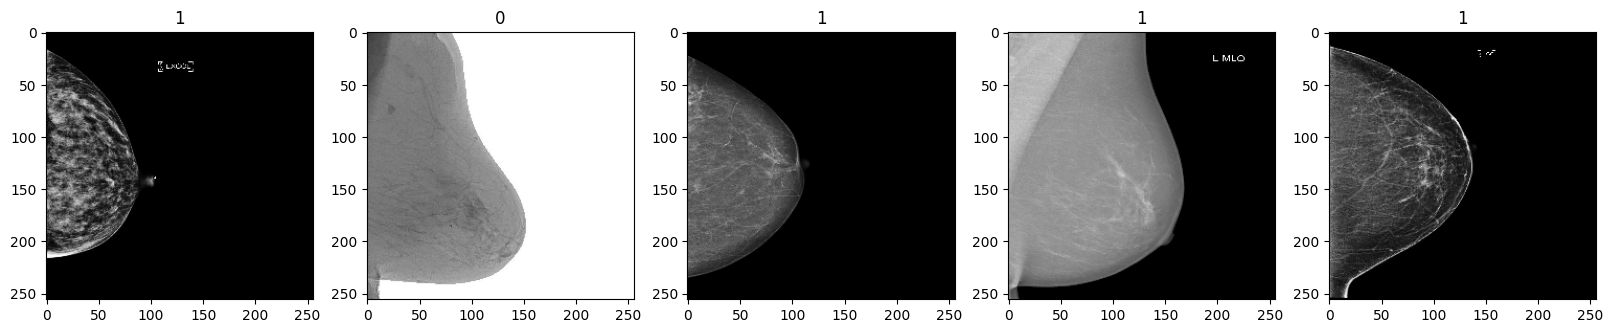

In [32]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

## Step 3 : Working on the training data

### the following few steps are just like the ones before but we work on the train directory only

In [33]:
datatrain = tf.keras.utils.image_dataset_from_directory('/kaggle/input/breast-cancer-detection-challenge/data/train/')

Found 2372 files belonging to 2 classes.


In [34]:
data_iterator = datatrain.as_numpy_iterator()

In [35]:
batch = data_iterator.next()

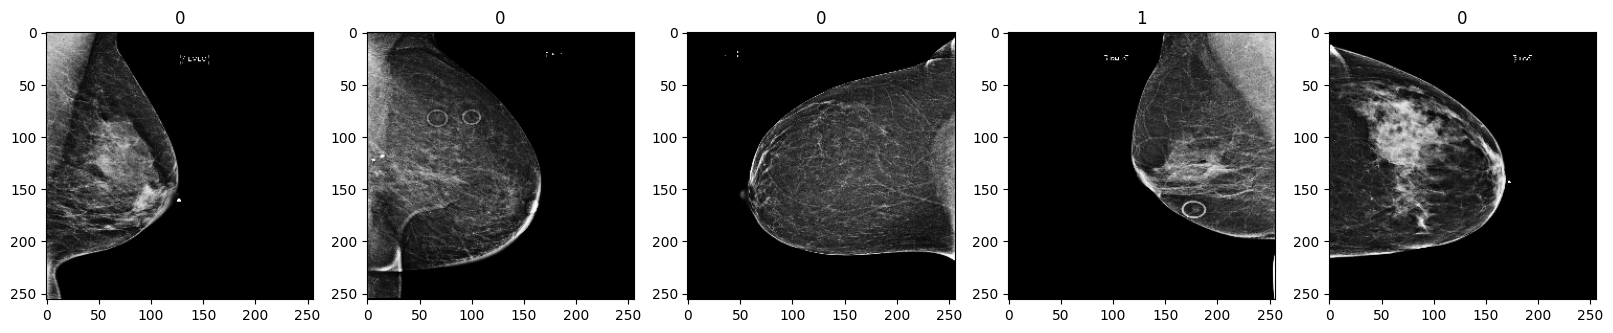

In [36]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

### 

### now we will scale the data according to the size of a standard pixel 255, in order to make all the values range between 0 and 1

In [37]:
datatrain = datatrain.map(lambda x,y: (x/255, y))

### we do this step in order to be able to know the shape of the train data right before training it

In [38]:
datatrain.as_numpy_iterator().next()

(array([[[[2.7132353e-01, 2.7132353e-01, 2.7132353e-01],
          [2.0784314e-01, 2.0784314e-01, 2.0784314e-01],
          [1.7205882e-01, 1.7205882e-01, 1.7205882e-01],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],
 
         [[3.6544117e-01, 3.6544117e-01, 3.6544117e-01],
          [2.4215686e-01, 2.4215686e-01, 2.4215686e-01],
          [1.8529412e-01, 1.8529412e-01, 1.8529412e-01],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],
 
         [[3.9362746e-01, 3.9362746e-01, 3.9362746e-01],
          [3.0710784e-01, 3.0710784e-01, 3.0710784e-01],
          [2.2647059e-01, 2.2647059e-01, 2.2647059e-01],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+

In [39]:
datatrain

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## Step 4 : building our deep learning model

### we start by importing sequential model and layers of keras api in order to build the neural network

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

### we initialize our model then add the layers 

In [41]:
model = Sequential()

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization

In [44]:
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))  
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dropout(0.5)) 
model.add(Dense(128, activation='relu')) 
model.add(Dropout(0.5))  
model.add(Dense(1, activation='sigmoid')) 


In [45]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

### this shows us the layers we added to our model (the architecture of our model)

In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,779,201 (33.49 MB)

 Trainable params: 8,778,241 (33.49 MB)

 Non-trainable params: 960 (3.75 KB)

### this is a directory we make to keep track of our train experiments

In [47]:
logdir='logs'

In [48]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

### we do the model training

In [49]:
hist = model.fit(datatrain, epochs=20,callbacks=[tensorboard_callback])

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.6494 - loss: 0.7310
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 317s 4s/step - accuracy: 0.6457 - loss: 0.7867
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy: 0.6578 - loss: 0.6691
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6735 - loss: 0.6410
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - accuracy: 0.6584 - loss: 0.6392
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.6540 - loss: 0.6544
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6531 - loss: 0.6463
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6642 - loss: 0.6635
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 322s 4s/step - accuracy: 0.6663 - loss: 0.6262
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy: 0.6668 - loss: 0.6252
Epoch 12/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6522 - loss: 0.6170
Epoch 13/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy

### we visualise the performance to see the evolution of the loss and accuracy 

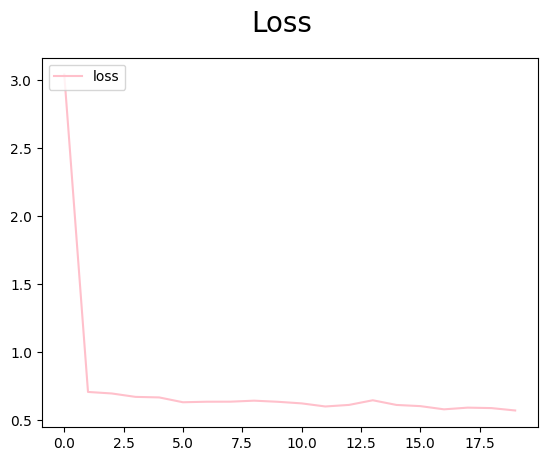

In [50]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='pink', label='loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

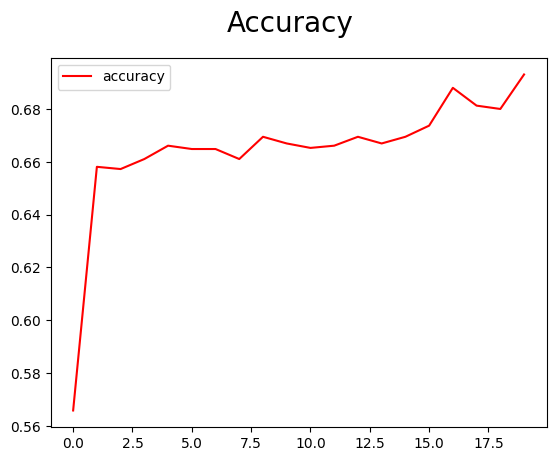

In [51]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='Red', label='accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

## Step 5 : testing our model

### I took one of the pictures in my test directory just to see how my model is working and if it's outputing results

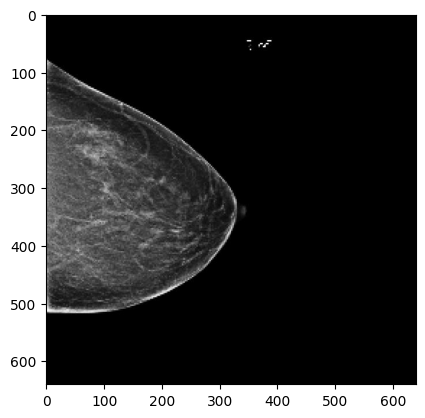

In [52]:
import cv2
img = cv2.imread('/kaggle/input/breast-cancer-detection-challenge/data/test/12651_382701440_png.rf.d76b15f48329258bbcd827676a155a84.jpg')
plt.imshow(img)
plt.show()

### we resize our image

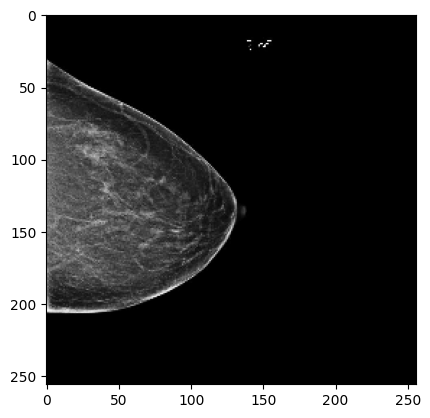

In [53]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

### we predict on this image that we put in 'resize'

In [54]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


In [55]:
yhat

array([[0.48256782]], dtype=float32)

### now I wanted to clasify the results of this picture so if it's above 50% then it's cancerous and under is benign (since we know 1 is cancerous cells and benign is 0)

In [56]:
if yhat > 0.5: 
    print(f'cancer')
else:
    print(f'benign')

benign


### this time I genrelized the prediction to all the files on the testing directory

#### first we put the data from our test directory into test_dir
#### then we loop through the images of the directory, during each iteration load our image and resize it
#### after that we make sure that the dimension of the image we gave matches with the input shape of our model
#### we make our prediction and classify it into one or 0 
#### and finally we store our results in 

In [57]:
test_dir = '/kaggle/input/breast-cancer-detection-challenge/data/test/'

filenames = []
predictions = []

for filename in os.listdir(test_dir):
    if filename.endswith('.jpg') or filename.endswith('.png'): 
        img_path = os.path.join(test_dir, filename)
        img = cv2.imread(img_path)
        resize = tf.image.resize(img, (256, 256))
        resize_normalized = resize / 255.0
        input_img = np.expand_dims(resize_normalized, axis=0) 
        yhat = model.predict(input_img)
        prediction = 1 if yhat[0][0] > 0.5 else 0
        
        # Store results
        filenames.append(filename)
        predictions.append(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

### we create a datadframe containing our results with the columns 'file_name' and 'label'

In [58]:
results = pd.DataFrame({
    'file_name': filenames,
    'label': predictions
})

### we finally save the results from our results dataframe into a 'submission.csv' file

In [59]:
results.to_csv('submission.csv', index=False)

print("Predictions saved to 'submission.csv'.")

Predictions saved to 'submission.csv'.
